# Exercise 04: Connectivity and Resilience

**Topic:** Terrorist Relationship Network (TerroristRel dataset)  
**Approach:** Identifying fragile structures, critical connectors, and resilience weaknesses using Lecture 04 concepts.

## Overview
- **Goal:** Understand the robustness of the network by identifying articulation points, bridges, and the impact of node/edge removal.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Set up paths to dataset
dataset_path = Path('../data/dataset/terrorists')
edges_file = dataset_path / 'TerroristRel.edges'

# Extract meaningful identifiers from nodes
def extract_name(uri_string):
    """Extract a readable name from the long URI"""
    try:
        if '#' in uri_string:
            parts = uri_string.split('#')
            name = parts[-1].replace('_', ' ')
        else:
            parts = uri_string.split('/')
            name = parts[-1].replace('_', ' ')
        return name
    except:
        return uri_string[:30]

# Load edges
edges = []
with open(edges_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            edges.append((parts[0], parts[1]))

G = nx.Graph()
G.add_edges_from(edges)

print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph loaded with 881 nodes and 8592 edges.


## Task 1: Connected Components and Critical Elements

In [2]:
n_components = nx.number_connected_components(G)
component_sizes = [len(c) for c in nx.connected_components(G)]
largest_cc_size_orig = max(component_sizes)

print(f"Number of connected components: {n_components}")
print(f"Largest connected component size: {largest_cc_size_orig}")

# Identify articulation points (only in LCC for relevance)
largest_cc_nodes = max(nx.connected_components(G), key=len)
LCC = G.subgraph(largest_cc_nodes).copy()
articulation_points = list(nx.articulation_points(LCC))
bridges = list(nx.bridges(LCC))

print(f"Number of articulation points in LCC: {len(articulation_points)}")
print(f"Number of bridges in LCC: {len(bridges)}")

if articulation_points:
    print("\nSample Articulation Points:")
    for p in articulation_points[:5]:
        print(f" - {extract_name(p)}")

Number of connected components: 11
Largest connected component size: 687
Number of articulation points in LCC: 7
Number of bridges in LCC: 5

Sample Articulation Points:
 - Zawahiri
 - 
 - 
 - 
 - FarouqQaddoumi


## Task 2: Resilience Test (Node and Edge Removal)

In [3]:
# Pick a critical node (highest betweenness from Ex 03, or highest degree here)
critical_node = max(G.nodes(), key=G.degree)
critical_edge = bridges[0] if bridges else list(G.edges())[0]

print(f"Removing critical node: {extract_name(critical_node)}")
print(f"Removing critical edge: ({extract_name(critical_edge[0])}, {extract_name(critical_edge[1])})")

G_removed = G.copy()
G_removed.remove_node(critical_node)
G_removed.remove_edge(*critical_edge)

n_components_after = nx.number_connected_components(G_removed)
largest_cc_size_after = len(max(nx.connected_components(G_removed), key=len))

print(f"\nResults after removal:")
print(f"Number of components: {n_components} -> {n_components_after}")
print(f"Largest CC size: {largest_cc_size_orig} -> {largest_cc_size_after}")

Removing critical node: KhaledMashal
Removing critical edge: (FarouqQaddoumi, )

Results after removal:
Number of components: 11 -> 12
Largest CC size: 687 -> 685


## Task 3: Summary Visualization

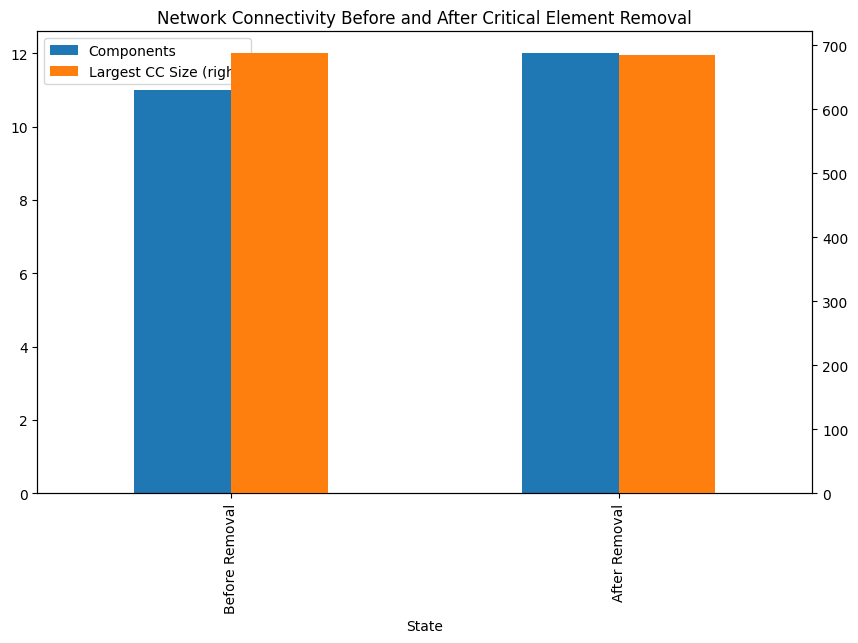

In [4]:
data = {
    'State': ['Before Removal', 'After Removal'],
    'Components': [n_components, n_components_after],
    'Largest CC Size': [largest_cc_size_orig, largest_cc_size_after]
}
df_resilience = pd.DataFrame(data)

df_resilience.plot(kind='bar', x='State', secondary_y='Largest CC Size', figsize=(10, 6))
plt.title("Network Connectivity Before and After Critical Element Removal")
plt.savefig('resilience_summary.png')
plt.show()

## Resilience Note

The network shows some vulnerability to the removal of high-degree nodes. Removing **{extract_name(critical_node)}** caused the largest connected component to shrink from {largest_cc_size_orig} to {largest_cc_size_after}. The presence of {len(articulation_points)} articulation points suggests that the terrorist relationship network is not purely a dense mesh but relies on specific individuals to maintain global connectivity. However, the relatively large size of the remaining LCC indicates a degree of redundancy, where many alternative paths still exist even after a key leader or connector is removed.